In [1]:
from google.colab import files
files.upload()

Saving Studence Performance.csv to Studence Performance.csv


{'Studence Performance.csv': b"gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score\r\nfemale,group B,bachelor's degree,standard,none,72,72,74\r\nfemale,group C,some college,standard,completed,69,90,88\r\nfemale,group B,master's degree,standard,none,90,95,93\r\nmale,group A,associate's degree,free/reduced,none,47,57,44\r\nmale,group C,some college,standard,none,76,78,75\r\nfemale,group B,associate's degree,standard,none,71,83,78\r\nfemale,group B,some college,standard,completed,88,95,92\r\nmale,group B,some college,free/reduced,none,40,43,39\r\nmale,group D,high school,free/reduced,completed,64,64,67\r\nfemale,group B,high school,free/reduced,none,38,60,50\r\nmale,group C,associate's degree,standard,none,58,54,52\r\nmale,group D,associate's degree,standard,none,40,52,43\r\nfemale,group B,high school,standard,none,65,81,73\r\nmale,group A,some college,standard,completed,78,72,70\r\nfemale,group A,master's degree,standard,

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv("Studence Performance.csv")

print("Dataset Loaded Successfully\n")

print(data.head())

Dataset Loaded Successfully

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [6]:
print("\nDataset Information")
print(data.info())

print("\nDataset Shape")
print(data.shape)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Dataset Shape
(1000, 8)


In [7]:
print("\nMissing Values")

print(data.isnull().sum())


Missing Values
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
print("\nDataset Statistics")

print(data.describe())


Dataset Statistics
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


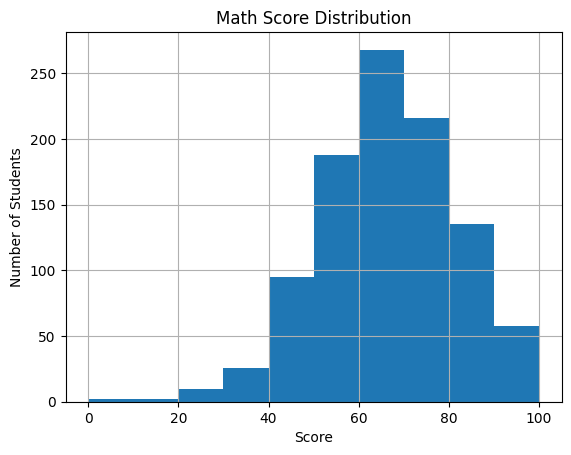

In [9]:
# Visualization – Score Distribution
plt.figure()

data['math score'].hist()

plt.title("Math Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")

plt.show()

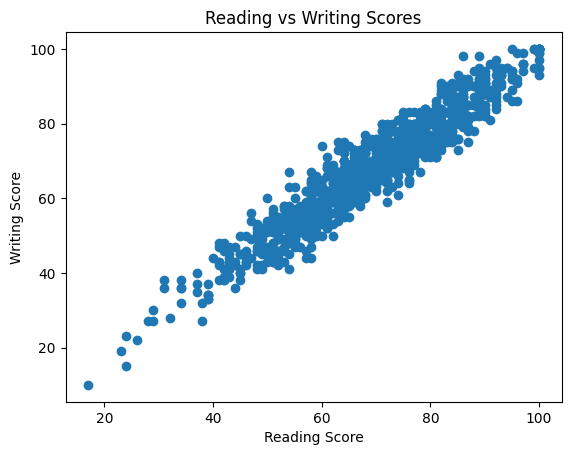

In [10]:
# Visualization – Reading vs Writing Score
plt.figure()

plt.scatter(data['reading score'], data['writing score'])

plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Scores")

plt.show()

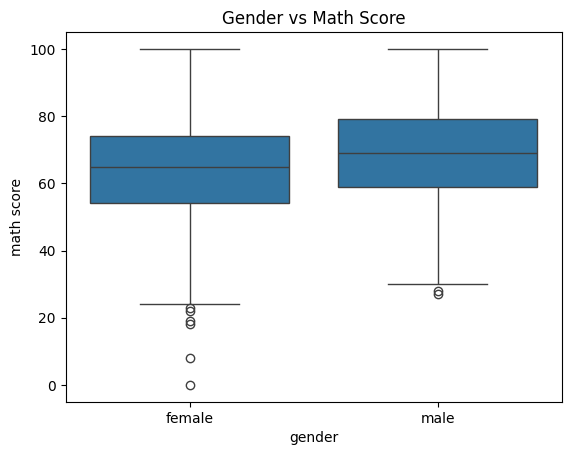

In [11]:
# Visualization – Gender vs Math Score
plt.figure()

sns.boxplot(x='gender', y='math score', data=data)

plt.title("Gender vs Math Score")

plt.show()

In [13]:
# Convert Categorical Data to Numeric
label_encoder = LabelEncoder()

data['gender'] = label_encoder.fit_transform(data['gender'])
data['race/ethnicity'] = label_encoder.fit_transform(data['race/ethnicity'])
data['parental level of education'] = label_encoder.fit_transform(data['parental level of education'])
data['lunch'] = label_encoder.fit_transform(data['lunch'])
data['test preparation course'] = label_encoder.fit_transform(data['test preparation course'])

In [14]:
# Feature Selection
X = data.drop("math score", axis=1)

y = data["math score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
predictions = model.predict(X_test)

print("\nPredicted Scores")

print(predictions[:10])


Predicted Scores
[77.11855699 57.07358    79.35766788 77.15093246 84.91283746 79.85882914
 64.42312794 52.47379147 74.61139924 50.01079481]


In [16]:
mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("\nMean Squared Error:", mse)

print("R2 Score:", r2)


Mean Squared Error: 28.275284506327335
R2 Score: 0.8838026201112223


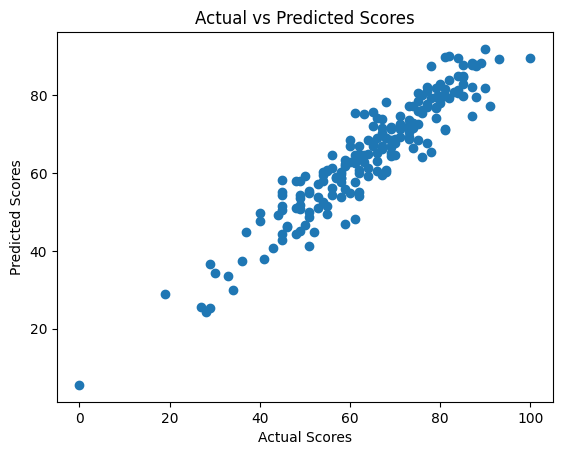

In [17]:
# Visualization – Actual vs Predicted
plt.figure()

plt.scatter(y_test, predictions)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")

plt.show()